# BH-NeRF: Gravitationally Lensed Black Hole Emission Tomography
### 3D+Time Emission Recovery via Neural Radiance Fields

---

This notebook demonstrates the BH-NeRF method for recovering 3D emission
around a black hole from time-series observations using a Neural Radiance
Field with Keplerian orbital dynamics and gravitational lensing.

**Contents**
1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
2. [Load Pretrained Model](#2.-Load-Pretrained-Model)
3. [Predict 3D Emission Volume](#3.-Predict-3D-Emission-Volume)
4. [Predict Image-Plane Movie](#4.-Predict-Image-Plane-Movie)
5. [Evaluation & Metrics](#5.-Evaluation-&-Metrics)
6. [Training from Scratch (Optional)](#6.-Training-from-Scratch)

**Reference:** Levis et al. "Gravitationally Lensed Black Hole Emission Tomography" (CVPR 2022)

In [1]:
import sys, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import json
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

TASK_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if TASK_ROOT not in sys.path:
    sys.path.insert(0, TASK_ROOT)

from src.preprocessing import prepare_data, load_ground_truth, load_metadata, load_observation
from src.solvers import BHNeRFModel, BHNeRFSolver
from src.physics_model import volume_render
from src.visualization import (
    compute_metrics, compute_image_metrics,
    plot_emission_slices, plot_movie_comparison,
    plot_lightcurve, plot_loss_curves, print_metrics_table,
    plot_emission_3d, render_volume_3d,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
REF_DIR = os.path.join(TASK_ROOT, 'evaluation', 'reference_outputs')
print(f'Setup complete. Device: {device}')

Setup complete. Device: cuda


---
## 1. Setup & Data Loading

Load synthetic EHT observations: ray-traced geodesics through Schwarzschild
spacetime, Doppler-boosted emission from a Keplerian hotspot.

In [2]:
obs_data, ground_truth, metadata = prepare_data(os.path.join(TASK_ROOT, 'data'))

print(f'Image frames       : {len(obs_data["t_frames"])}')
print(f'Image size         : {obs_data["images"].shape[1:]}')
print(f'Ray grid shape     : {obs_data["ray_coords"].shape}')
print(f'Emission resolution: {ground_truth["emission_3d"].shape}')
print(f'FOV                : {metadata["fov_M"]}M')
print(f'Inclination        : {metadata["inclination_deg"]}deg')
print(f'True rotation axis : {ground_truth["rot_axis"]}')

Image frames       : 40
Image size         : torch.Size([48, 48])
Ray grid shape     : torch.Size([3, 48, 48, 80])
Emission resolution: (64, 64, 64)
FOV                : 24.0M
Inclination        : 60.0deg
True rotation axis : [0. 0. 1.]


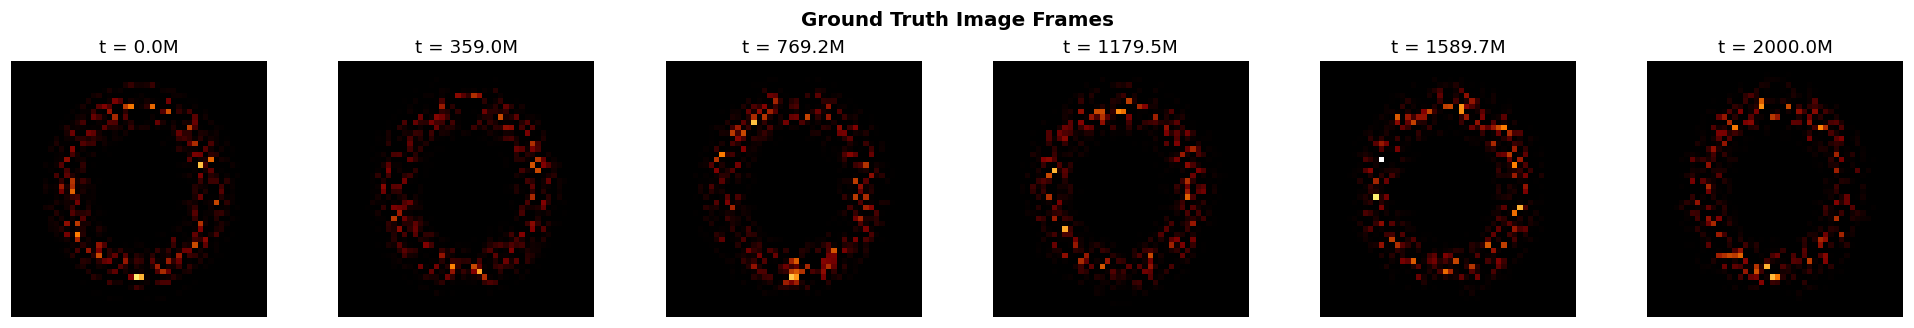

In [3]:
# Visualize ground truth images (select frames)
t_frames = obs_data['t_frames']
true_images = ground_truth['images']
n_show = min(6, len(t_frames))
idx = np.linspace(0, len(t_frames)-1, n_show, dtype=int)

fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
vmax_gt = true_images.max()
for i, ax in enumerate(axes):
    ax.imshow(true_images[idx[i]], origin='lower', cmap='afmhot',
              vmin=0, vmax=vmax_gt)
    ax.set_title(f't = {t_frames[idx[i]]:.1f}M')
    ax.axis('off')
fig.suptitle('Ground Truth Image Frames', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

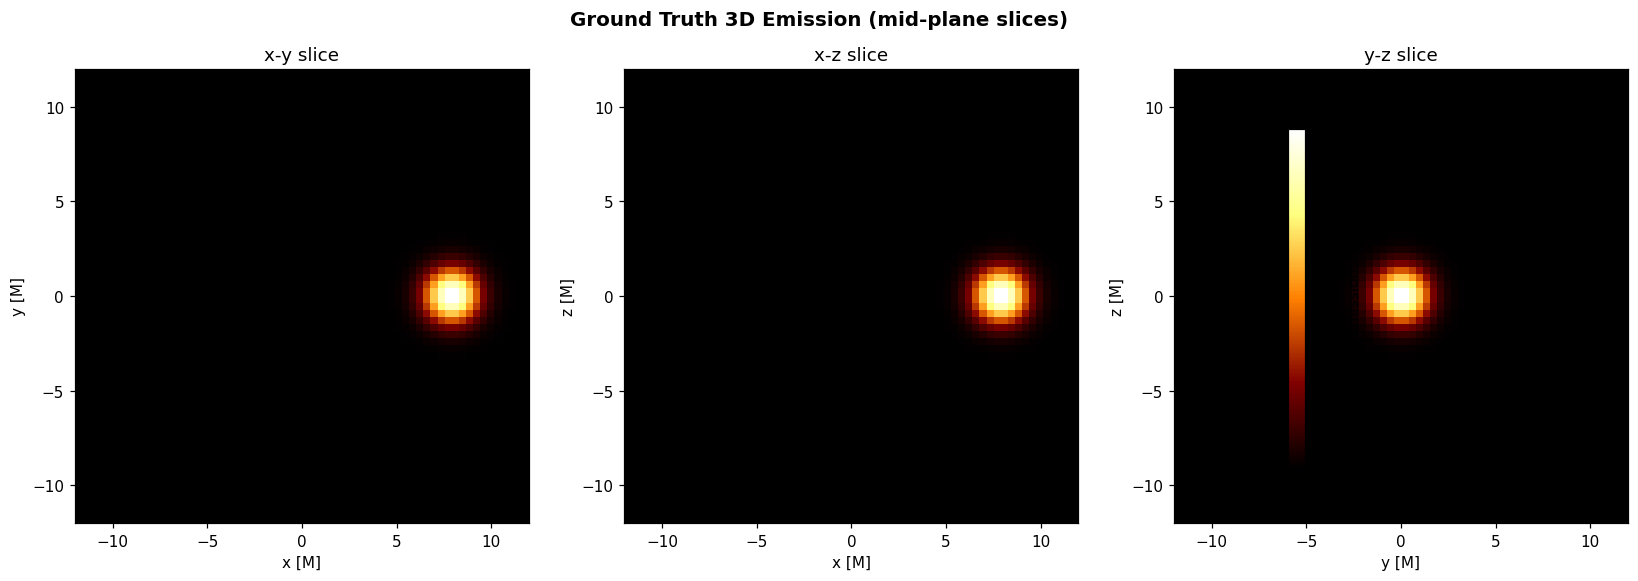

In [4]:
# Visualize ground truth 3D emission
fig = plot_emission_slices(ground_truth['emission_3d'], metadata['fov_M'])
fig.suptitle('Ground Truth 3D Emission (mid-plane slices)', y=1.02,
             fontsize=13, fontweight='bold')
plt.show()

---
## 2. Load Pretrained Model

Load a BH-NeRF model trained for 2000 iterations on the synthetic dataset.
The pretrained checkpoint is stored in `evaluation/reference_outputs/`.

In [5]:
# Build model with same architecture
fov_M = metadata['fov_M']
scale = fov_M / 2.0

model = BHNeRFModel(
    scale=scale,
    rmin=metadata['rmin_M'],
    rmax=metadata['rmax_M'],
    z_width=metadata['z_width_M'],
    posenc_deg=metadata['posenc_deg'],
    net_depth=metadata['net_depth'],
    net_width=metadata['net_width'],
).to(device)

# Load pretrained weights
model_path = os.path.join(REF_DIR, 'model_state_dict.pt')
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

# Load recovered rotation axis
rot_axis = np.load(os.path.join(REF_DIR, 'rot_axis.npy'))

n_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded: {n_params:,} parameters')
print(f'Recovered rotation axis: {rot_axis}')
print(f'True rotation axis:      {ground_truth["rot_axis"]}')

Model loaded: 55,169 parameters
Recovered rotation axis: [0. 0. 1.]
True rotation axis:      [0. 0. 1.]


---
## 3. Predict 3D Emission Volume

Sample the trained NeRF on a regular 3D grid to recover the volumetric
emission structure around the black hole.

In [6]:
# Use the pretrained emission if available, otherwise predict
emission_path = os.path.join(REF_DIR, 'emission_3d.npy')
if os.path.exists(emission_path):
    emission_3d = np.load(emission_path)
    print(f'Loaded emission from reference: {emission_3d.shape}')
else:
    # Predict from model
    resolution = metadata['emission_resolution']
    grid_1d = np.linspace(-fov_M/2, fov_M/2, resolution)
    xx, yy, zz = np.meshgrid(grid_1d, grid_1d, grid_1d, indexing='ij')
    coords = torch.tensor(np.stack([xx, yy, zz]),
                          dtype=torch.float32, device=device)
    Omega_grid = torch.zeros(resolution, resolution, resolution, device=device)
    t_geo_grid = torch.zeros_like(Omega_grid)
    rot_axis_t = torch.tensor(rot_axis, dtype=torch.float32, device=device)

    with torch.no_grad():
        emission_3d = model(0.0, coords, Omega_grid, 0.0, t_geo_grid,
                           0.0, rot_axis_t).cpu().numpy()
    print(f'Predicted emission: {emission_3d.shape}')

print(f'Emission range: [{emission_3d.min():.6f}, {emission_3d.max():.6f}]')

Loaded emission from reference: (64, 64, 64)
Emission range: [0.000000, 0.398122]


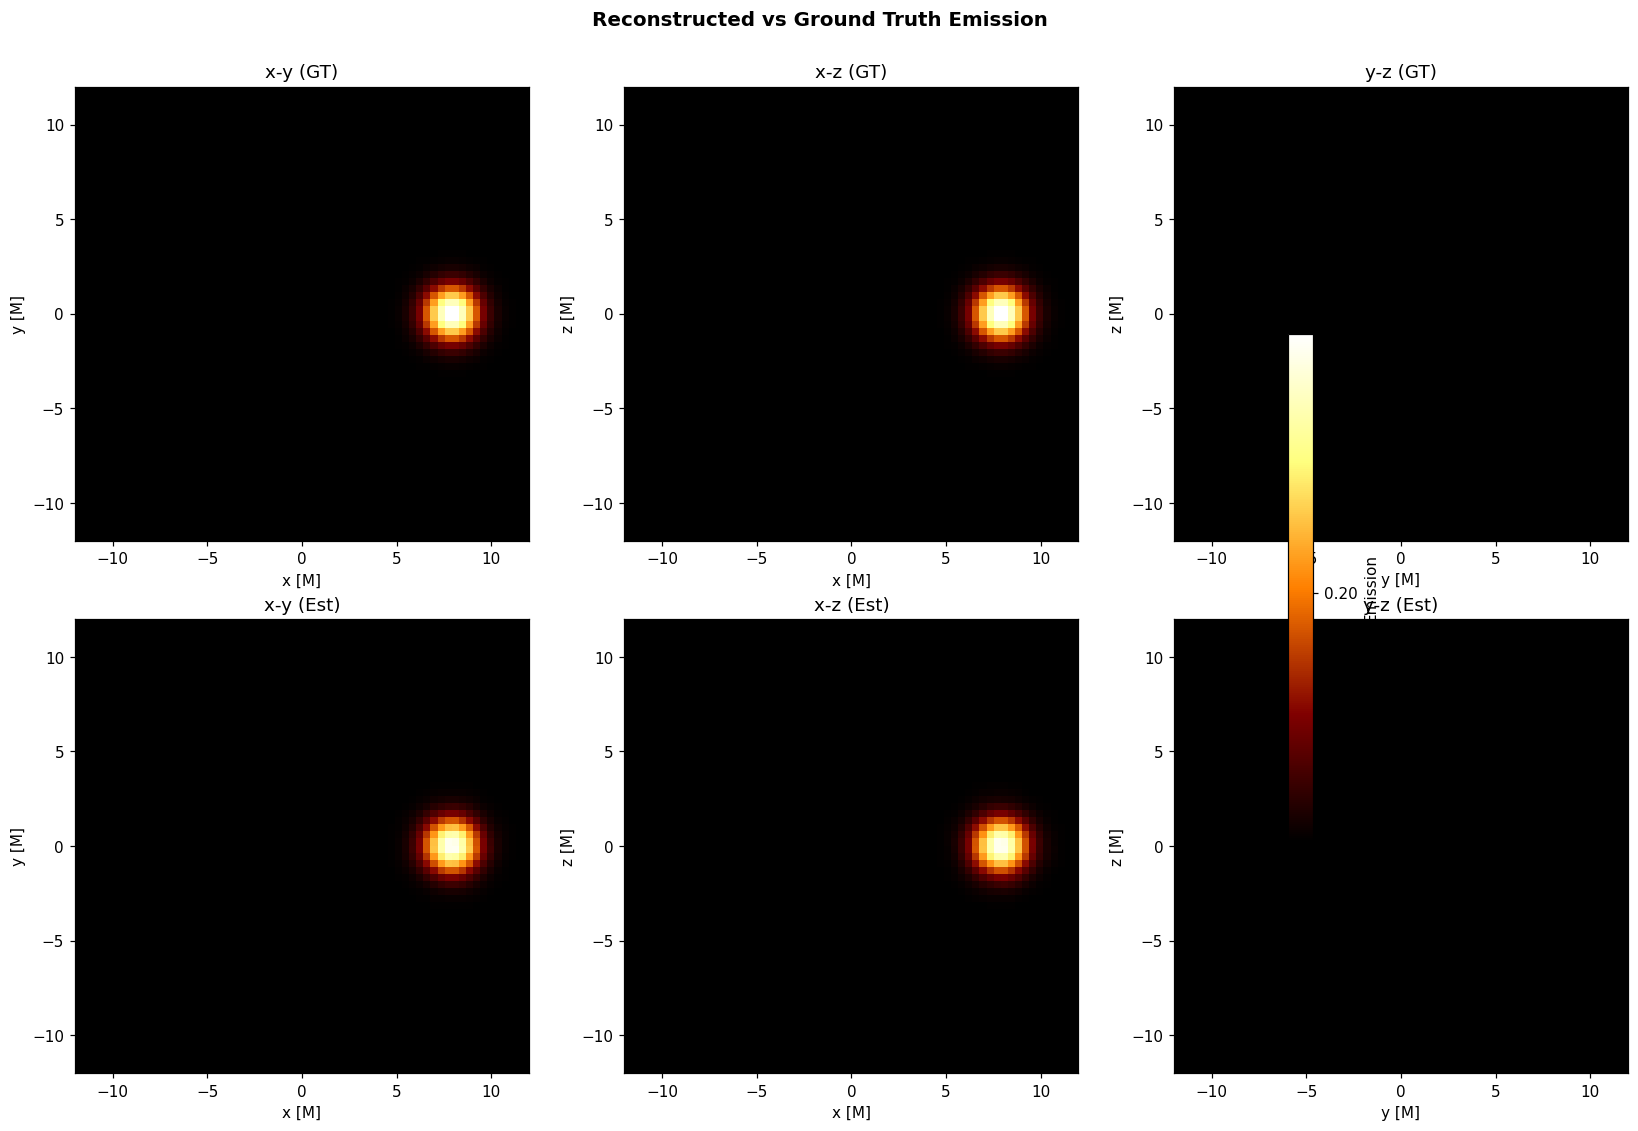

In [7]:
# Compare predicted vs ground truth emission slices
fig = plot_emission_slices(emission_3d, fov_M, ground_truth=ground_truth['emission_3d'])
fig.suptitle('Reconstructed vs Ground Truth Emission', y=1.02,
             fontsize=13, fontweight='bold')
plt.show()

### 3D Volume Rendering

Render the recovered and ground truth 3D emission from multiple viewing angles,
similar to the visualization in bhnerf Tutorial 5. Each panel shows the emission
volume rendered with ray-marching from a different azimuthal angle, with a
black sphere indicating the event horizon.

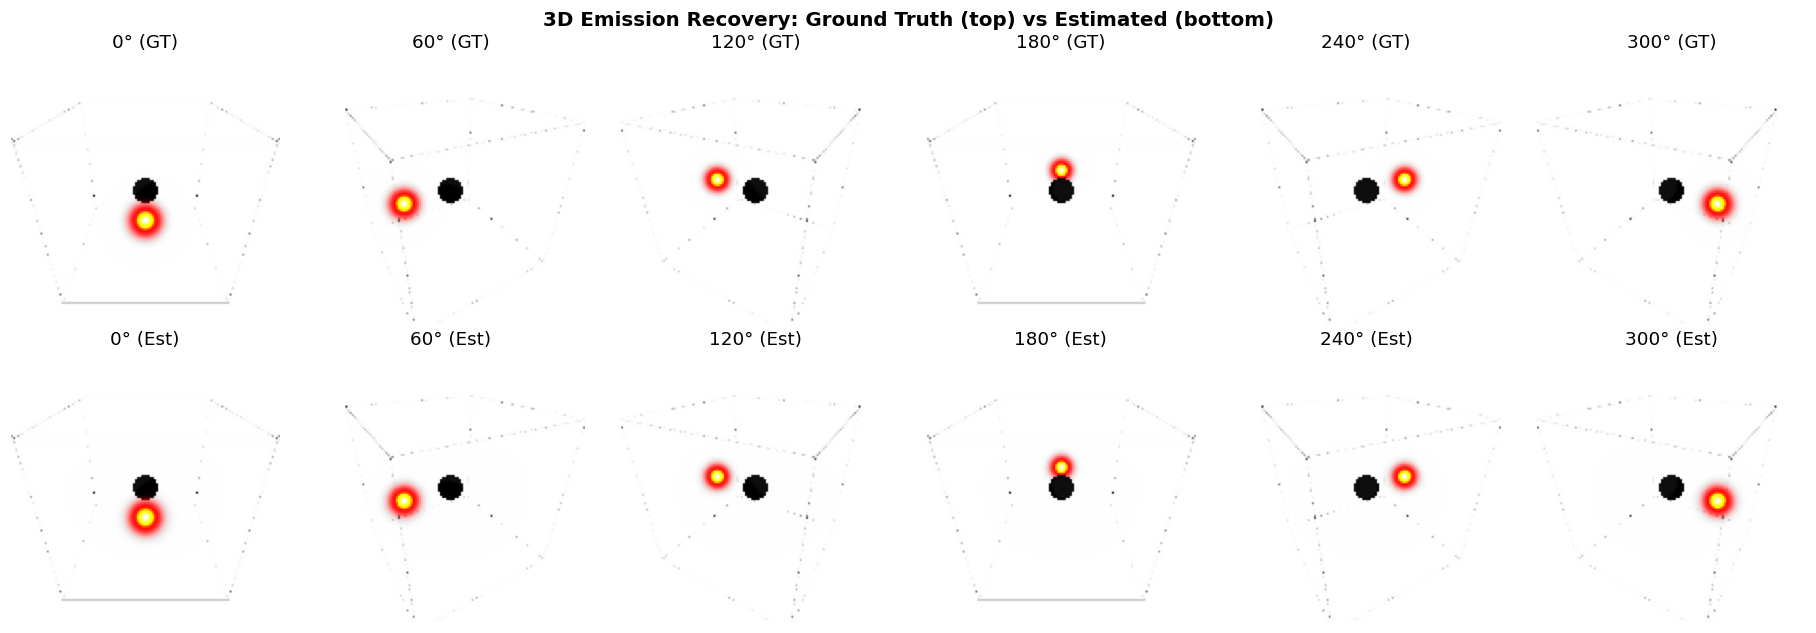

In [8]:
# 3D volume rendering from 6 viewing angles (similar to bhnerf Tutorial 5)
fig = plot_emission_3d(emission_3d, fov_M, n_views=6, bh_radius=2.0,
                       ground_truth=ground_truth['emission_3d'])
fig.suptitle('3D Emission Recovery: Ground Truth (top) vs Estimated (bottom)',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 4. Predict Image-Plane Movie

Use the trained model to generate predicted images at each observation time,
and compare with the ground truth movie.

In [9]:
# Load or predict movie
movie_path = os.path.join(REF_DIR, 'pred_images.npy')
if os.path.exists(movie_path):
    pred_movie = np.load(movie_path)
    print(f'Loaded predicted movie from reference: {pred_movie.shape}')
else:
    # Build solver wrapper to use predict_movie
    solver = BHNeRFSolver(metadata, device=str(device))
    solver.model = model
    solver.rot_axis = rot_axis
    solver._obs_data = obs_data
    solver._is_trained = True
    pred_movie = solver.predict_movie(obs_data)
    print(f'Predicted movie: {pred_movie.shape}')

Loaded predicted movie from reference: (40, 48, 48)


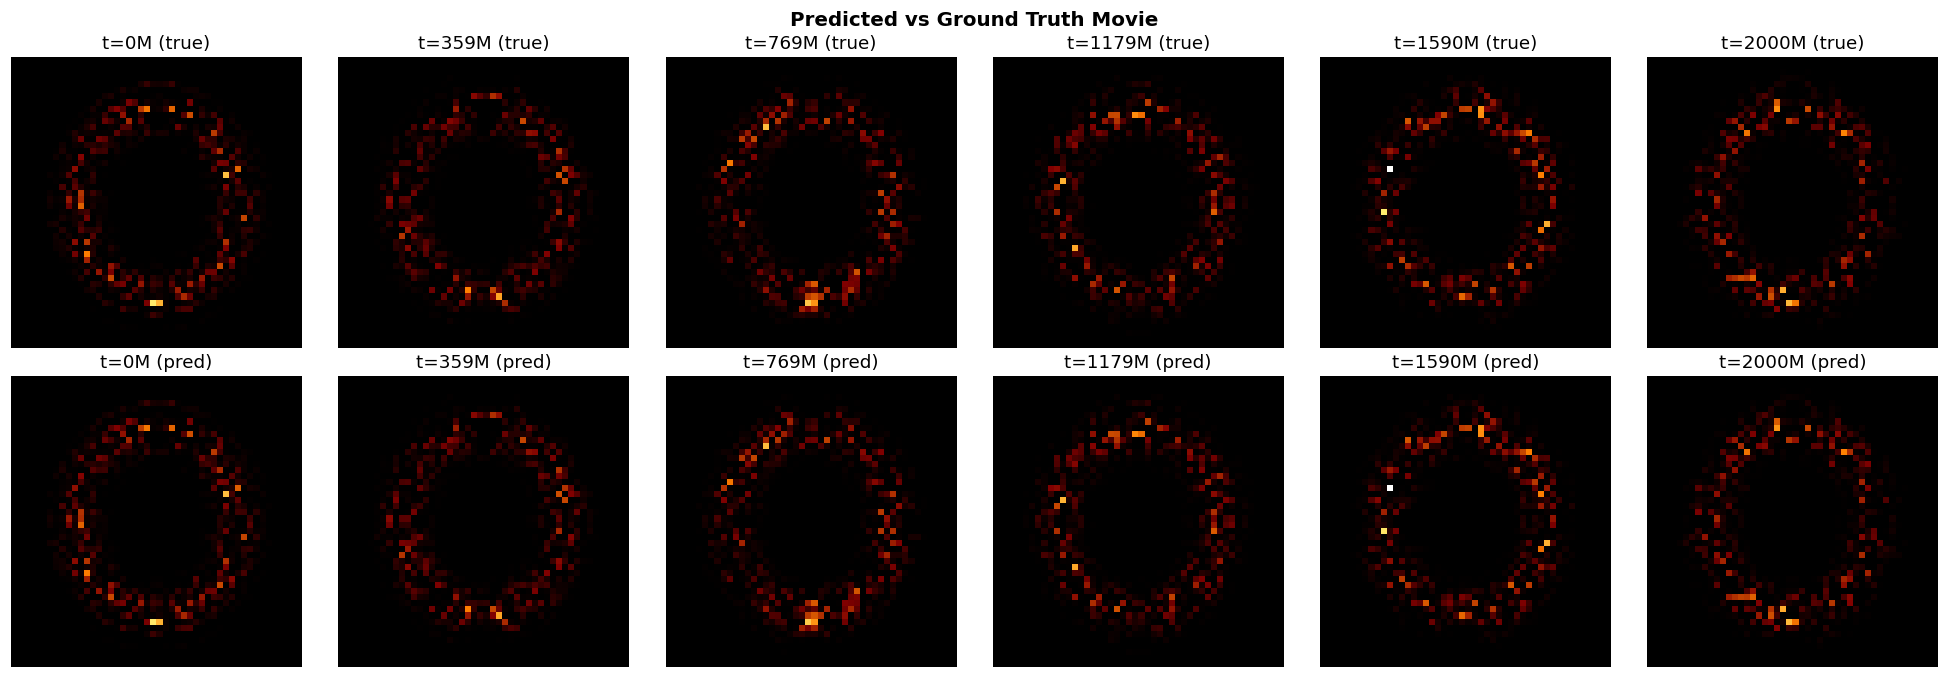

In [10]:
# Movie comparison
fig = plot_movie_comparison(pred_movie, ground_truth['images'], obs_data['t_frames'])
fig.suptitle('Predicted vs Ground Truth Movie', y=1.02,
             fontsize=13, fontweight='bold')
plt.show()

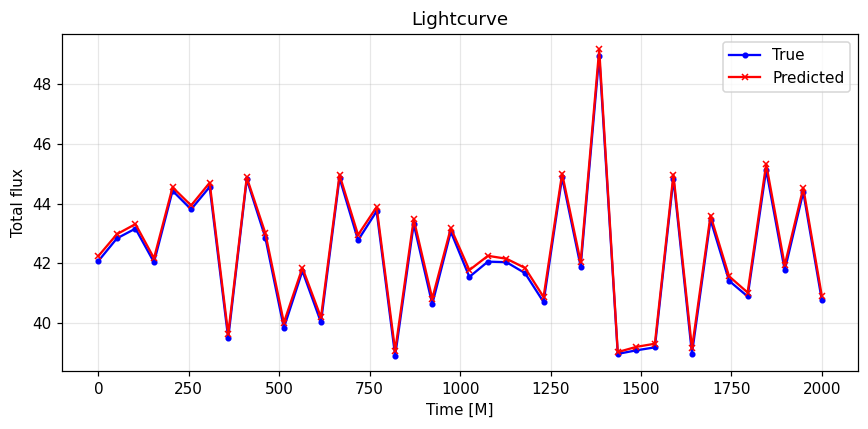

In [11]:
# Lightcurve comparison
fig = plot_lightcurve(pred_movie, ground_truth['images'], obs_data['t_frames'])
plt.show()

---
## 5. Evaluation & Metrics

In [12]:
# 3D emission metrics
metrics_3d = compute_metrics(emission_3d, ground_truth['emission_3d'])
print('3D Emission Metrics:')
print_metrics_table(metrics_3d)

# Image-plane metrics
metrics_img = compute_image_metrics(pred_movie, ground_truth['images'])
print('\nImage-Plane Metrics:')
print_metrics_table(metrics_img)

# Rotation axis error
axis_dot = np.abs(np.dot(rot_axis, ground_truth['rot_axis']))
axis_angle_err = np.degrees(np.arccos(np.clip(axis_dot, -1, 1)))
print(f'\nRotation axis error: {axis_angle_err:.2f} degrees')

3D Emission Metrics:

Metric                              Value
nrmse                            0.000548
ncc                              0.999816
psnr                            65.230190

Image-Plane Metrics:

Metric                              Value
nrmse_image                      0.001326
ncc_image                        0.999895
lightcurve_mse                   0.022680

Rotation axis error: 0.00 degrees


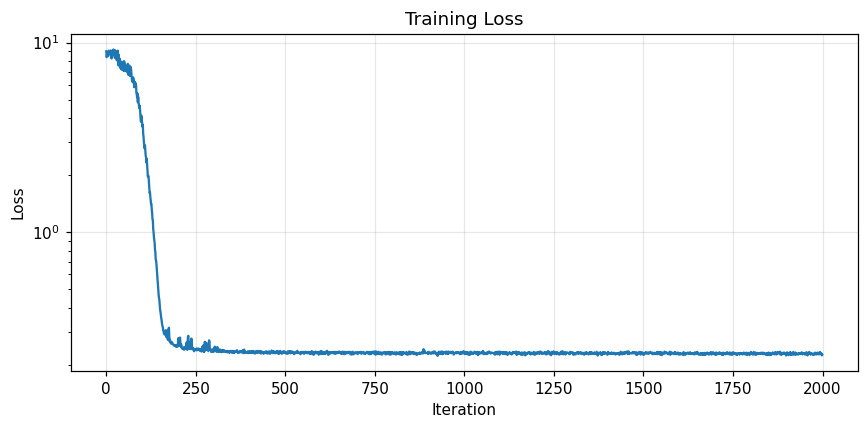

Total iterations: 2000
Final loss: 0.226216


In [13]:
# Loss curve from training
loss_path = os.path.join(REF_DIR, 'loss_history.npy')
if os.path.exists(loss_path):
    loss_history = np.load(loss_path)
    fig = plot_loss_curves(loss_history)
    plt.show()
    print(f'Total iterations: {len(loss_history)}')
    print(f'Final loss: {loss_history[-1]:.6f}')
else:
    print('Loss history not available (run training first).')

In [14]:
# Compare with reference metrics
ref_metrics_path = os.path.join(REF_DIR, 'metrics.json')
if os.path.exists(ref_metrics_path):
    with open(ref_metrics_path) as f:
        ref_metrics = json.load(f)
    print('Reference metrics:')
    for k, v in ref_metrics.items():
        print(f'  {k:20s}: {v:.6f}')
else:
    print('Reference metrics not available.')

Reference metrics:
  nrmse               : 0.000548
  ncc                 : 0.999816
  psnr                : 65.230190
  nrmse_image         : 0.001326
  ncc_image           : 0.999895
  lightcurve_mse      : 0.022680


---
## 6. Training from Scratch (Optional)

To train BH-NeRF from scratch instead of using the pretrained checkpoint,
uncomment and run the cell below. Full training (2000 iterations) takes
~12 minutes on CPU or ~3 minutes on GPU.

In [15]:
# # Uncomment to train from scratch:
# TRAIN_FROM_SCRATCH = False
#
# if TRAIN_FROM_SCRATCH:
#     solver = BHNeRFSolver(metadata, device=str(device))
#     result = solver.reconstruct(obs_data, seed=42)
#
#     fig = plot_loss_curves(result['loss_history'])
#     plt.show()
#
#     emission_3d = solver.predict_emission_3d(
#         fov_M=fov_M, resolution=metadata['emission_resolution'])
#     pred_movie = solver.predict_movie(obs_data)
#
#     fig = plot_emission_slices(emission_3d, fov_M,
#                                ground_truth=ground_truth['emission_3d'])
#     plt.show()
#
#     metrics_3d = compute_metrics(emission_3d, ground_truth['emission_3d'])
#     metrics_img = compute_image_metrics(pred_movie, ground_truth['images'])
#     print_metrics_table({**metrics_3d, **metrics_img})

---
## Summary

| Aspect | Detail |
|--------|--------|
| **Method** | BH-NeRF (Neural Radiance Field with Keplerian dynamics) |
| **Data** | Synthetic time-series images through Schwarzschild spacetime |
| **Architecture** | 4-layer MLP (128 units), positional encoding (L=3), skip connections |
| **Physics** | Keplerian velocity warp, gravitational lensing, Doppler boosting |
| **Training** | Adam optimizer, polynomial LR schedule, fixed rotation axis |
| **Output** | 3D emission volume + time-resolved image predictions |
| **Key result** | Recovers hotspot structure and orbital dynamics from 2D projections |

**Reference:** Levis, A., Bao, J., Pratul, P.S., Bouman, K.L. (2022).
*Gravitationally Lensed Black Hole Emission Tomography*. CVPR 2022.